

# Python Variables & the Memory Model

When you create a variable in Python, you're not storing a value directly inside it — you're giving a name to an object that lives in memory, and that name simply points to it. This distinction shapes how copying, passing data to functions, and modifying data actually behave in Python. 

In this notebook we'll explore how Python manages variables internally, and see some examples with practical implications.





<br>



## 1. Python's variables are not like buckets



In other programming languages (e.g. C, JavaScript...) variables can often be seen as boxes that hold a value.

In Python, variables are names bound to objects. Assignment never copies data — it just points a label at an object in memory.

→ Main idea: in Python, variables are names bound to objects

<br><br>

Here's a diagram illustrating how data is stored in Python:

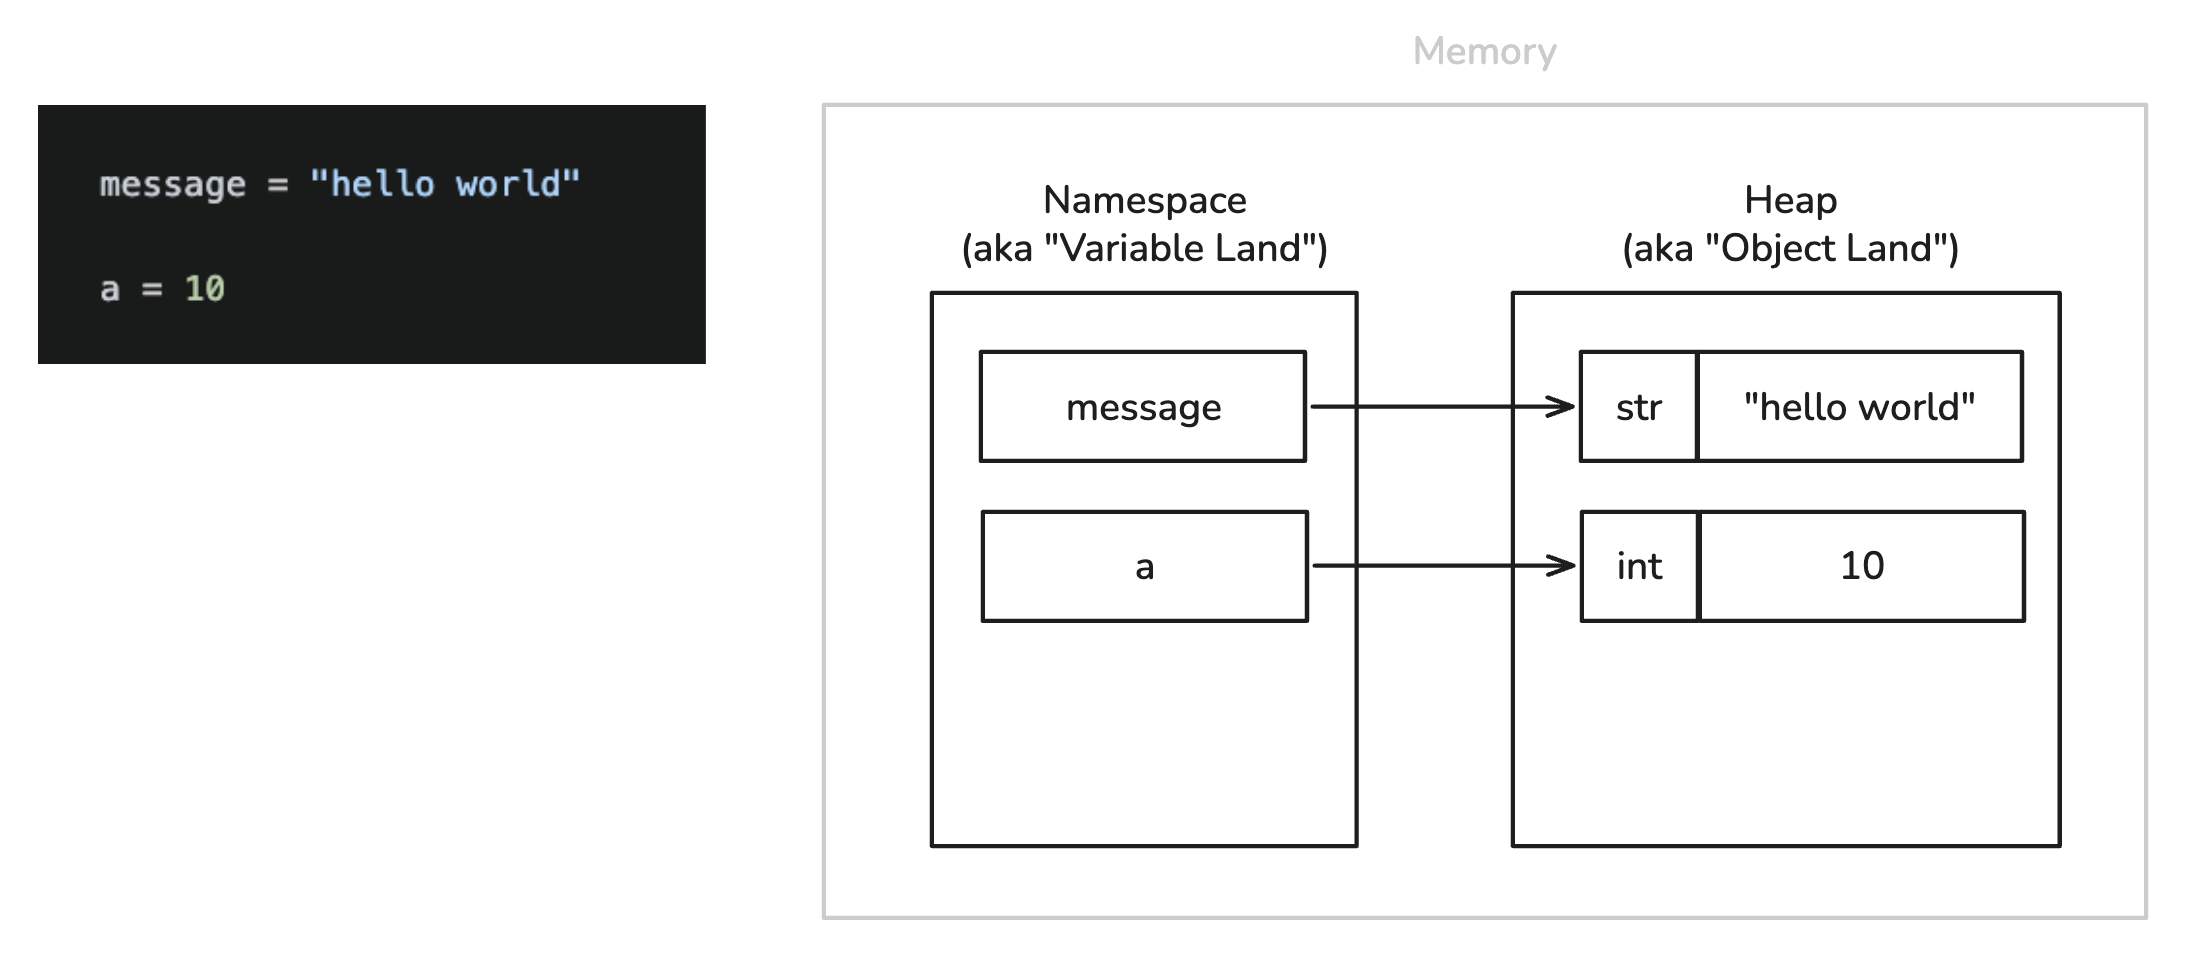




<br>

We can actually see where those variables point to, using the function `id()`.

The `id()` function in Python returns a unique integer identifier for an object (its memory address). 

Note: the main use cases for this function are debugging or teaching, as it helps verify if two variables reference the same object. 





In [1]:

message = "hello world"

a = 10

print(id(message))  # e.g. 4466445680
print(id(a))        # e.g. 4357729144

4463602096
4354009976


<br>

The difference between `is` vs `==`:

- `==` checks value equality
- `is` checks "same object in memory" (same `id()`).


In [2]:
a = [1, 2, 3]
b = [1, 2, 3]
print(a == b)   # True  (same contents)
print(a is b)   # False (different objects)

c = a
print(a is c)   # True  (both of them point to the same object in memory)

True
False
True


<br>

## 2. Internally, everything is an object

In Python, everything is an object. This applies to all data types: numbers (int, float...), strings (str), booleans (bool), lists (list), None, functions... internally, every value is stored as an object in memory


Note: 
- If you're familiar with OOP: when we say an object, we mean an instance of a class (with attributes and methods).
- If you're not familiar with OOP: think of an object as a complex data structure that allows you to store information and functionality in the same place.



In [3]:

message = "Hello World" 

user = {"name": "alice", "age": 30}

print(
    f"\nThe variable 'message'... \n"
    f"is of type: {type(message)} \n"
    f"and it points to this memory address {id(message)}"
)

print(
    f"\nThe variable 'user'... \n"
    f"is of type: {type(user)} \n"
    f"and it points to this memory address {id(user)}"
)


#
# Since the variable "message" is a string, it has some specific methods available.
# List with string methods: https://www.w3schools.com/PYTHON/python_ref_string.asp
#
# for example, we can invoke the methods .upper(), .count()...
#
print("\n")
print(message.upper()) 
print(message.count("o"))


#
# Since the variable "user" is a dictionary, it has some specific methods available.
# List with string methods: https://www.w3schools.com/python/python_ref_dictionary.asp
#
# for example, we can invoke the methods .get(), .keys()...
#
print("\n")
print(user.get("age")) 
print(user.keys())



The variable 'message'... 
is of type: <class 'str'> 
and it points to this memory address 4463752688

The variable 'user'... 
is of type: <class 'dict'> 
and it points to this memory address 4463823040


HELLO WORLD
2


30
dict_keys(['name', 'age'])


<br>

## 3. Mutable vs. Immutable

In Python, every object is either mutable or immutable.

Immutable objects:
- Cannot be changed. Any "modification" actually creates a new object.
- Examples: int, float, bool, str, tuple, ...

Mutable objects:
- Can be changed after they are created.
- Examples: list, dict, set, ...



In [4]:
#
# Example with a IMMUTABLE object
#

s = "hello"     # a string is an immutable object
print(id(s))

s += " world"   # if we modify the variable, Python is actually creating a new object
print(id(s))    # now, it points to a new address in memory



4459320864
4463626352


In [5]:
#
# Example with an MUTABLE object
#

numbers = [1, 2, 3] # a list is a mutable object
print(id(numbers))

numbers.append(4)   # if we modify the variable, python will modify the same object (it doesn't create a new one)
print(id(numbers))        # it still points to the same address in memory



4463827904
4463827904


<br>

## 4. Shared References and Side Effects

In Python, when you assign an existing object to a new variable (e.g., b = a), Python does not create a copy of the object. Instead, it copies the reference (the memory pointer).

For mutable objects like lists or dictionaries, this means both variables now point to the exact same object in memory. Modifying the object through one variable will automatically change it for the other.


In [6]:
#
# Example with an "immutable" object
#

amount = 10
amount_copy = amount    # we're actually copying the REFERENCE (not the actual data)
print(id(amount) == id(amount_copy))    # True (they point to the same address in memory)

# An int is an immutable object. If we modify the variable, Python is actually creating a new object.
amount_copy += 50

# Now, they point to different addresses in memory.
print(id(amount) == id(amount_copy))   # False 


print(amount_copy)
print(amount, "← we didn't modify the original")



True
False
60
10 ← we didn't modify the original


In [7]:
#
# Now, let's do a similar example, but now with a "mutable" object
#

numbers = [10, 10, 10]
numbers_copy = numbers  # we're actually copying the REFERENCE (not the actual data)
print(id(numbers) == id(numbers_copy))  # True (they point to the same address in memory)

# A list is a mutable object. If we modify the variable, Python will also modify the original
numbers_copy.append(50)

# We can see that they still point to the same address in memory.
print(id(numbers) == id(numbers_copy))   # True 

print(numbers_copy)
print(numbers, "← in this case, we have also mutated the original")



True
True
[10, 10, 10, 50]
[10, 10, 10, 50] ← in this case, we have also mutated the original


<br>

Key takeaways 📌
- Assignment (`b = a`) copies the reference, not the data.
- For immutable types (int, str, tuple…) this is safe — any "modification" produces a new object.
- For mutable types (list, dict, set…) both variables point to the same object, so mutating one affects the other (we'll learn how to avoid that in the next section)



<br>

## 5. Preventing Side Effects from Shared References

When you need an independent object, do not assign with `b = a` for mutable types.

Three practical rules:
- Create a copy when you need independence.
- Prefer immutable data types when possible.
- Avoid mutating function inputs unless that is explicit and intentional.

In [8]:
# Creating an independent copy for flat (non-nested) lists

original = [1, 2, 3]

copy_a = original.copy()  # creates an independent list (aka "shallow copy")
copy_b = list(original)   # creates an independent list (another way to create a "shallow copy")

copy_a.append(50)
copy_b.append(50)

print("original:", original)
print("copy_a:", copy_a)
print("copy_b:", copy_b)

# we can see that the original and the copies point to a different address in memory
print("\nidentity checks")
print("original is copy_a:", original is copy_a)    # False
print("original is copy_b:", original is copy_b)    # False


original: [1, 2, 3]
copy_a: [1, 2, 3, 50]
copy_b: [1, 2, 3, 50]

identity checks
original is copy_a: False
original is copy_b: False


<br>

### Shallow copy vs deep copy

For nested objects (e.g., list of lists, dicts containing lists):
- A shallow copy duplicates only the outer container.
- Inner mutable objects are still shared.
- Use `copy.deepcopy(...)` when you need full independence.

In [9]:
# Nested structure pitfall: shallow copy still shares inner objects

import copy

original = [[1, 2], [3, 4]] # a list of lists (ie. a nested data structure)

#
# If we use a shallow copy...
#
shallow = original.copy()
shallow[0].append(99)

print("\nResults after shallow copy mutation:")
print("original:", original)  # we have changed the original
print("shallow:", shallow)
print("same outer object?", original is shallow)          # False
print("same first inner object?", original[0] is shallow[0])  # True

# Deep copy: full independence for nested mutable objects
deep = copy.deepcopy(original)
deep[0].append(77)

print("\nResults after deep copy mutation:")
print("original:", original)  # unchanged by deep mutation
print("deep copy:", deep)
print("same first inner object?", original[0] is deep[0])  # False


Results after shallow copy mutation:
original: [[1, 2, 99], [3, 4]]
shallow: [[1, 2, 99], [3, 4]]
same outer object? False
same first inner object? True

Results after deep copy mutation:
original: [[1, 2, 99], [3, 4]]
deep copy: [[1, 2, 99, 77], [3, 4]]
same first inner object? False


In [10]:
# Example of safe function design: avoid mutating the input unless explicitly intended

def add_tax_unsafe(prices, tax):
    # Mutates the caller's list in place
    for i in range(len(prices)):
        prices[i] = round(prices[i] * (1 + tax), 2)
    return prices

def add_tax_safe(prices, tax):
    # Works on a copy and returns a new list
    result = prices.copy()
    for i in range(len(result)):
        result[i] = round(result[i] * (1 + tax), 2)
    return result

items = [100, 200, 300]
print("before unsafe:", items)
unsafe_result = add_tax_unsafe(items, 0.10)
print("unsafe_result:", unsafe_result)
print("items after unsafe:", items)

items = [100, 200, 300]
print("\nbefore safe:", items)
safe_result = add_tax_safe(items, 0.10)
print("safe_result:", safe_result)
print("items after safe:", items)  # unchanged

before unsafe: [100, 200, 300]
unsafe_result: [110.0, 220.0, 330.0]
items after unsafe: [110.0, 220.0, 330.0]

before safe: [100, 200, 300]
safe_result: [110.0, 220.0, 330.0]
items after safe: [100, 200, 300]


<br>

Key takeaways 📌
- Use `.copy()` or `list(original)` to get an independent shallow copy of a flat container.
- For nested structures, a shallow copy only duplicates the outer container — inner mutable objects are still shared. Use `copy.deepcopy()` when you need full independence.
- Prefer returning a new object from functions rather than mutating the input, unless mutation is the explicit intent.
- Immutable types (tuple, frozenset…) are inherently safe to share — consider using them when the data should not change.



<br>

## 6. The Mutable Default Argument Trap

Python evaluates default argument values **once**, when the function is **defined** — not each time the function is called.

This means if you use a mutable object (like a list or dict) as a default, all calls share the exact same object in memory. This is one of the most common Python gotchas.


In [11]:

# The bug: a mutable list used as a default argument

def add_item(item, cart=[]):
    cart.append(item)
    return cart

# Call the function twice without providing a cart
order_1 = add_item("apple")
order_2 = add_item("banana")

print("order_1:", order_1)   # expected: ['apple']
print("order_2:", order_2)   # expected: ['banana']

# Both variables point to the same default list object!
print("\nSame object?", order_1 is order_2)   # True
print("id of order_1:", id(order_1))
print("id of order_2:", id(order_2))


order_1: ['apple', 'banana']
order_2: ['apple', 'banana']

Same object? True
id of order_1: 4463845504
id of order_2: 4463845504


In [12]:

# The default list lives on the function object itself — we can inspect it directly

def add_item(item, cart=[]):
    cart.append(item)
    return cart

print("defaults before any call:", add_item.__defaults__)

add_item("apple")
print("defaults after 1st call: ", add_item.__defaults__)

add_item("banana")
print("defaults after 2nd call: ", add_item.__defaults__)

# The same list keeps growing across every call


defaults before any call: ([],)
defaults after 1st call:  (['apple'],)
defaults after 2nd call:  (['apple', 'banana'],)



<br>

The fix: use `None` as a sentinel

The idiomatic Python solution is to use `None` as the default value and create the mutable object **inside** the function body. This way, a fresh object is created on every call.


In [13]:

# The fix: use None as the default sentinel

def add_item_safe(item, cart=None):
    if cart is None:
        cart = []       # a new list is created on every call
    cart.append(item)
    return cart

order_1 = add_item_safe("apple")
order_2 = add_item_safe("banana")

print("order_1:", order_1)   # ['apple']
print("order_2:", order_2)   # ['banana']

print("\nSame object?", order_1 is order_2)   # False — independent lists

# Passing an explicit cart still works as expected
shared_cart = []
add_item_safe("apple", shared_cart)
add_item_safe("banana", shared_cart)
print("\nshared_cart:", shared_cart)   # ['apple', 'banana']


order_1: ['apple']
order_2: ['banana']

Same object? False

shared_cart: ['apple', 'banana']



<br>

Rule of thumb for default arguments 📌
- **Never use mutable objects (`[]`, `{}`, `set()`) as default argument values.**
- Instead, use `None` and initialise inside the function body.

<br>

```python
# Avoid
def my_function(data=[]):
    # ...
    # ...

# Prefer
def my_function(data=None):
    if data is None:
        data = []
    # ...
    # ...
    
```

Note: intentionally sharing state via a mutable default (e.g. a simple in-function cache) is possible but rare — always document it explicitly if you do.
